# ML Coursework 2

This notebook implements TypiClust, an active learning strategy introduced in the paper "Active Learning on a Budget: Opposite Strategies Suit High and Low Budgets".

This implementation focuses on the variant that uses SimCLR for representation learning and K-Means for clustering.

## Setup

In [1]:
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch", "torchvision", "scikit-learn", "numpy", "tqdm", "pytorch-metric-learning", "umap-learn", "matplotlib", "pandas"])


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


0

In [2]:
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
import torch.optim as optim

import torchvision
from torchvision import models
import torchvision.transforms as transforms

import random
import numpy as np

from torch.utils.data import DataLoader, Subset
from torch.utils.data.dataloader import default_collate
from tqdm import tqdm
from pytorch_metric_learning.losses import NTXentLoss, SelfSupervisedLoss

from sklearn.random_projection import GaussianRandomProjection
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import umap

from sklearn.cluster import KMeans, MiniBatchKMeans
import matplotlib.pyplot as plt
import copy
import json
import glob
import pandas as pd

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def set_seed(seed):
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)
  random.seed(seed)
  torch.backends.cudnn.deterministic = True

## File Paths

In [4]:
if IN_COLAB:
    DATA_PATH = '/content/drive/MyDrive/mlcoursework2_k21008618/datasets/cifar10'
    MODEL_SAVE_PATH = '/content/drive/MyDrive/mlcoursework2_k21008618/simclr/simclr_model.pth'
    EMBEDDING_PATH = '/content/drive/MyDrive/mlcoursework2_k21008618/simclr/simclr_embeddings.pt'
    RESULTS_DIR = '/content/drive/MyDrive/mlcoursework2_k21008618/results'
    PLOTS_DIR = '/content/drive/MyDrive/mlcoursework2_k21008618/plots'
else:
    DATA_PATH = './datasets/cifar10'
    MODEL_SAVE_PATH = './simclr/simclr_model.pth'
    EMBEDDING_PATH = './simclr/simclr_embeddings.pt'
    RESULTS_DIR = './results'
    PLOTS_DIR = './plots'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
os.makedirs(os.path.dirname(EMBEDDING_PATH), exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

## Load Datasets for all experiments

In [5]:
"""
The augmentations used by the paper were: random resized crops, random horizontal
flips, colour jittering, and random greyscale.
"""
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(32),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

fully_supervised_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

normalise = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

dataset_train = torchvision.datasets.CIFAR10(root=DATA_PATH, train=True, download=True, transform=None)

NUM_TRAIN = len(dataset_train)

normalised_train =  torchvision.datasets.CIFAR10(root=DATA_PATH, train=True, download=True, transform=normalise)
normalised_test = torchvision.datasets.CIFAR10(root=DATA_PATH, train=False, download=True, transform=normalise)

dataset_train_fully_supervised = torchvision.datasets.CIFAR10(root=DATA_PATH, train=True, download=True, transform=fully_supervised_transform)
dataset_test_fully_supervised = normalised_test

dataset_train_self_supervised_embeddings = normalised_train
dataset_test_self_supervised_embeddings = normalised_test

## SimCLR Implementation

SimCLR is a self-supervised contrastive learning method. A model is trained to learn image representations, where two augmentations of the same image should have similar embeddings, and augmentations of different images should have dissimilar ones.

### Dataset Augmentations

For each image, SimCLR generates two different augmented views using a series of transformations.

In [6]:
class AugmentedPairsDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, index):
        image, _ = self.dataset[index]

        img1 = self.transform(image)
        img2 = self.transform(image)

        return img1, img2

    def __len__(self):
        return len(self.dataset)

### Resnet Model

A cnn model encodes each augmented image into a feature vector.

In [7]:
PROJECTION_DIM = 128
HIDDEN_DIM = 512

class ResnetModel(nn.Module):
    """
    A resnet18 model without pretrained weights.
    The final classification layer is removed from the model and a projection layer is added.
    The projection layer is used for contrastive learning.
    The base cnn layer is used for feature representations.
    """
    def __init__(self):

        super().__init__()

        resnet_model = models.resnet18(weights=None)

        resnet_model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        resnet_model.maxpool = nn.Identity()

        num_features = resnet_model.fc.in_features
        # remove the final classification layer
        resnet_model.fc = nn.Identity()

        self.base_cnn = resnet_model

        # two layer MLP with relu
        self.projection_layer = nn.Sequential(
            nn.Linear(num_features, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, PROJECTION_DIM)
        )

    def forward(self, x):
        features = self.base_cnn(x)
        projection = self.projection_layer(features)
        return projection

### Training Code

The training procedure of SimCLR:
- get a batch of unlabelled images
- apply random augmentations to each image
- pass both views through the model
- calculate contrastive loss on each pair
- backpropagate and update model weights

The paper uses a ResNet18 with an MLP projection layer to a 128-d vector, trained for 500 epochs. After training, the 512-d penultimate layer is used for the representation space.

An SGD optimiser with a 0.9 momentum, and an initial learning rate of 0.4 with a cosine scheduler is used. The batch size is 512 and weight decay is 0.0001.

In [8]:
BATCH_SIZE = 512
NUM_EPOCHS = 500
LEARNING_RATE = 0.4
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0001

def train_model():
    """
    Train a cnn model on the unlabelled pool to learn a semantically meaningful feature space.
    """
    set_seed(42)

    augmented_dataset = AugmentedPairsDataset(dataset_train, simclr_transform)
    trainloader = DataLoader(augmented_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    model = ResnetModel().to(device)

    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=LEARNING_RATE * (0.1 ** 3))
    nt_xent_loss = SelfSupervisedLoss(NTXentLoss(temperature=0.5))

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0

        for img1, img2 in tqdm(trainloader):
            img1, img2 = img1.to(device), img2.to(device)

            optimizer.zero_grad()

            outputs1 = model(img1)
            outputs2 = model(img2)

            loss = nt_xent_loss(outputs1, outputs2)
            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1} | Loss: {running_loss / len(trainloader):.4f}")

        scheduler.step()

    torch.save(model.state_dict(), MODEL_SAVE_PATH)

if not os.path.exists(MODEL_SAVE_PATH):
    train_model()
else:
    print("SimCLR model already exists.")

SimCLR model already exists.


## TypiClust Implementation

TypiClust is composed of 3 following main steps:

1. Representaiton learning
2. Clustering for diversity
3. Querying typical examples

### Representation Learning



Feature vectors of the data are extracted using the penultimate layer of the trained model. L2 normalisation is applied to each vector.

In [9]:
BATCH_SIZE = 512

def representation_learning(dataset):
    """
    This function uses the trained model to extract embeddings for training set.
    """

    if not os.path.exists(MODEL_SAVE_PATH):
        raise FileNotFoundError(f"Model weights not found at {MODEL_SAVE_PATH}")

    model = ResnetModel().to(device)
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))

    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model.eval()
    embeddings = [] # stores the embeddings for the entire dataset
    all_labels = [] # stores the labels for the data points

    # run all the images through the model
    with torch.no_grad():
        for imgs, batch_labels in dataloader:
            imgs = imgs.to(device)
            # get feature vectors
            features = model.base_cnn(imgs)
            # normalise feature vectors: essential for typicality calculations and KMeans
            # the paper uses L2 normalised penultimate layer as embeddings
            features = F.normalize(features, dim=1)
            embeddings.append(features.cpu())
            all_labels.append(batch_labels)

    # collect all embeddings into a single tensor
    return torch.cat(embeddings, dim=0), torch.cat(all_labels, dim=0)

### K-Means Clustering

For K-means clustering, the number of clusters was limited to 500 for CIFAR-10. This was done to prevent over clustering and to stabilize clustering.
KMeans is used for 50 or less clusters, otherwise MiniBatchKmeans is used.

In [10]:
MAX_CLUSTERS = 500

def k_means_clustering_algorithm(embeddings, budget, num_labelled):
    set_seed(42)
    # the number of clusters is limited to 500 to prevent over clustering
    num_clusters = min(num_labelled + budget, MAX_CLUSTERS)

    # to reduce runtime, MiniBatchKMeans is used for more than 50 clusters
    if num_clusters <= 50:
        kmeans = KMeans(n_clusters=num_clusters)
    else:
        kmeans = MiniBatchKMeans(n_clusters=num_clusters, batch_size=5000)

    # a list the same size as the dataset, where each item indicates the cluster class
    labels = kmeans.fit_predict(embeddings.numpy())

    return labels

### Typicality

The typicality of a data point is defined by its density in some semantically meaningful feature space. It is measured by the inverse of the average euclidean distance to its K nearest neighbours.

In [ ]:
def calculate_typicality(x, cluster_embeddings, k):
    """
    x: embedding of a single data point
    cluster_embeddings: embeddings of all data points in a cluster
    k: number of nearest neighbours

    Typicality of a data points is defined by its density in a feature space.
    It is measured by the inverse of the average euclidean distance to its K nearest neighbours.
    """
    # calculate the euclidean distance from x to every other point in cluster
    euclidean_distances = torch.norm(cluster_embeddings - x, dim=1)

    # k + 1 (includes distance from itself)
    num_neighbours = min(k + 1, len(euclidean_distances))

    # get the list of k+1 smallest distances of neigbours from x
    smallest_distances, _ = torch.topk(euclidean_distances, num_neighbours, largest=False)

    # drop the first distance (0 = distance from x itself)
    k_dists = smallest_distances[1:]

    if len(k_dists) == 0:
        return float('inf')

    # average the distance of the k nearest neighbours
    avg_dist = k_dists.mean()

    # return the inverse of the average distance
    return 1.0 / avg_dist.item() if avg_dist > 0 else float('inf')

### TypiClust

In [12]:
MIN_CLUSTER_SIZE = 5
TYPICALITY_NEIGHBOURS = 20

def typiClust(budget, unlabelled_indices, labelled_indices, model=None):
    """
    budget : the number of data points that can be labelled per iteration
    unlabelled_indices: the list of indices of unlabelled data points
    labelled_indices: indices corresponding to data points that have been labelled

    This variant of typiClust is uses SIMCLR for representation
    Learning and K-means for clustering.
    """
    # extract the feature vectors using the penultimate layer of the trained model
    if os.path.exists(EMBEDDING_PATH):
        embeddings = torch.load(EMBEDDING_PATH)
    else:
        embeddings, _ = representation_learning(normalised_train)
        torch.save(embeddings, EMBEDDING_PATH)

    queries = []
    labelled_set = set(labelled_indices)

    # cluster the data
    cluster_labels = k_means_clustering_algorithm(embeddings, budget, len(labelled_set))
    cluster_labels = torch.tensor(cluster_labels)

    # group together datapoints in the same clusters
    clusters = {}
    for idx, cluster_class in enumerate(cluster_labels):
        c = cluster_class.item()
        if c not in clusters:
            clusters[c] = []
        clusters[c].append(idx)

    # query one unlabelled data point for each iteration in allowed budget
    for _ in range(budget):
        best_cluster = None
        least_labelled_count = float('inf')
        largest_cluster_size = -1

        # go through all clusters
        for cluster_class, data_indices in clusters.items():
            # clusters with less than 5 samples are dropped
            if len(data_indices) < MIN_CLUSTER_SIZE:
                continue

            # number of labelled data points in this cluster
            labelled_count_in_cluster = len(set(data_indices) & labelled_set)

            # find largest cluster with the fewest labelled points
            less_labelled = labelled_count_in_cluster < least_labelled_count
            cluster_is_larger = labelled_count_in_cluster == least_labelled_count and len(data_indices) > largest_cluster_size

            if less_labelled or cluster_is_larger:
                least_labelled_count = labelled_count_in_cluster
                largest_cluster_size = len(data_indices)
                best_cluster = cluster_class

        if best_cluster is None:
            break

        # get unlabelled data points
        cluster_data_indices = clusters[best_cluster]
        unlabelled_data_indices = [idx for idx in cluster_data_indices if idx not in labelled_set]

        if len(unlabelled_data_indices) == 0:
            del clusters[best_cluster]
            continue

        all_cluster_data_indices = torch.tensor(cluster_data_indices)
        all_cluster_data_embeddings = embeddings[all_cluster_data_indices]
        num_nearest_neighbours = min(TYPICALITY_NEIGHBOURS, len(all_cluster_data_indices))

        # keep track of data point with the highest typicality
        highest_typicality_score = -1
        most_typical_dataset_idx = None

        # go through each unlabelled data point in the cluster and calculate typicality
        for local_idx, dataset_idx in enumerate(cluster_data_indices):
            if dataset_idx in labelled_set:
                continue

            typicality_score = calculate_typicality(all_cluster_data_embeddings[local_idx], all_cluster_data_embeddings, num_nearest_neighbours)

            if typicality_score > highest_typicality_score:
                highest_typicality_score = typicality_score
                most_typical_dataset_idx = dataset_idx

        # the most typical data points needs to be queried
        queries.append(most_typical_dataset_idx)
        labelled_set.add(most_typical_dataset_idx)

    return queries

### Testing TypiClust

In [13]:
torch.manual_seed(42)

budget = 10
queries = typiClust(budget, list(range(NUM_TRAIN)), [])

result = "Test passed!!" if len(queries) == budget else 'Test failed!!'
print(result)

Test passed!!


# Results Replication

## Fully Supervised

The fully supervised framework uses a budget of 10 and 5 active learning iterations. A resnet18 was trained on the datapoints selected by the active learning strategies, optimising with SGD with 0.9 momentum and Nesterov momentum. The initial learning rate is 0.025, and was modified using a cosine scheduler. The augmentations are random crops and horizontal flips. The training ran for 200 epochs and the weights are re-initialised between active learning iterations.  

### Baselines

In [14]:
def softmax_distributions(model, indices, batch_size=256):
    model.eval()
    all_probs = []

    with torch.no_grad():
        for start in range(0, len(indices), batch_size):
            batch_indices = indices[start:start + batch_size]
            images = torch.stack([normalised_train[i][0] for i in batch_indices]).to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu())

    return torch.cat(all_probs, dim=0)


def random_uniformly(budget, unlabelled_indices, labelled_indices=None, model=None):
    """
    Select random data points within a certain budget.
    """
    labelled = np.random.choice(len(unlabelled_indices), size=budget, replace=False)

    return [unlabelled_indices[i] for i in labelled]

def uncertainty(budget, unlabelled_indices, labelled_indices=None, model=None):
    """
    The model picks the data points that it is least certain about.
    """
    # probablity distribution
    probabilities = softmax_distributions(model, unlabelled_indices)
    # get the highest probability for each data point
    maximum_probabilities = probabilities.max(dim=1).values
    # get data points with the smallest probabilities
    _, most_uncertain = maximum_probabilities.topk(budget, largest=False)
    return [unlabelled_indices[i] for i in most_uncertain.numpy()]

def margin(budget, unlabelled_indices, labelled_indices=None, model=None):
    """
    Pick data points where the difference between the highest and second
    highest class probabilities is the least.
    """
    # probablity distribution
    probabilities = softmax_distributions(model, unlabelled_indices)
    # get two highest class probabilities
    top_class_probabilities = probabilities.topk(2, dim=1).values
    # get the difference between them
    margins = top_class_probabilities[:, 0] - top_class_probabilities[:, 1]  # [N]
    # pick data points with the smallest margin, means that the model has a hard time deciding
    _, most_uncertain = margins.topk(budget, largest=False)

    return [unlabelled_indices[i] for i in most_uncertain.numpy()]

def entropy(budget, unlabelled_indices, labelled_indices=None, model=None):
    """
    The model picks data points where the class predictions are the most spread
    out. It computes shannon entropy of each datapoint's distribution.
    If the entropy is high then the probability is distributed evenly across classes.
    """
    # probablity distribution
    probabilities = softmax_distributions(model, unlabelled_indices)
    # the shannon entropy formula
    ent = -(probabilities * (probabilities + 1e-10).log()).sum(dim=1)
    # get data points with the highest entropy
    _, highest_entropy = ent.topk(budget, largest=True)

    return [unlabelled_indices[i] for i in highest_entropy.numpy()]

def coreset(budget, unlabelled_indices=None, labelled_indices=None, model=None):
    """
    This function selects samples that are as spread out as possible in the
    feature space.
    """
    if os.path.exists(EMBEDDING_PATH):
        features = torch.load(EMBEDDING_PATH).numpy()
    else:
        features, _ = representation_learning(normalised_train)
        features = features.numpy()

    unlabelled_pool = np.array(unlabelled_indices)
    pool_features = features[unlabelled_pool]

    first = np.random.randint(len(unlabelled_pool))
    selected = [first]

    for _ in range(1, budget):
        dists = np.full(len(unlabelled_pool), np.inf)
        for s in selected:
            d = np.linalg.norm(pool_features - pool_features[s], axis=1)
            dists = np.minimum(dists, d)
        dists[selected] = -1
        selected.append(int(np.argmax(dists)))

    return [int(unlabelled_pool[i]) for i in selected]

fully_supervised_strategies = [
    ('Random', random_uniformly),
    ('Uncertainty', uncertainty),
    ('Margin', margin),
    ('Entropy', entropy),
    ('Coreset', coreset),
    ('TypiClust', typiClust),
]

### Training

In [15]:
BUDGET = 10
ITERATIONS = 5
REPETITIONS = 10
EPOCHS = 200
LEARNING_RATE = 0.025
MOMENTUM = 0.9

def train_supervised(labelled_indices):
  train_sampler = torch.utils.data.SubsetRandomSampler(labelled_indices)

  train_loader = DataLoader(dataset_train_fully_supervised, batch_size=64, sampler=train_sampler, num_workers=2)
  test_loader = DataLoader(dataset_test_fully_supervised, batch_size=256, shuffle=False, num_workers=2)

  # re-initialise weights between iterations
  model = torchvision.models.resnet18(num_classes=10).to(device)
  optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, nesterov=True)
  scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

  model.train()
  pbar = tqdm(range(EPOCHS), desc="Training", leave=False)
  for epoch in pbar:
      for images, labels in train_loader:
          images, labels = images.to(device), labels.to(device)
          loss = F.cross_entropy(model(images), labels)
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()
      scheduler.step()

  model.eval()
  correct, total = 0, 0
  with torch.no_grad():
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          preds = model(images).argmax(dim=1)
          correct += (preds == labels).sum().item()
          total += labels.size(0)

  accuracy = 100.0 * correct / total
  return accuracy, model

### Experiment

In [16]:
def fully_supervised_experiment(strategy_name, selection_strategy):
    checkpoint_path = os.path.join(RESULTS_DIR, f'fully_supervised_{strategy_name}_checkpoint.npz')

    if os.path.exists(checkpoint_path):
        checkpoint = np.load(checkpoint_path)
        accuracies = checkpoint['accuracies']
        start_repitition = int(checkpoint['completed_reps'])
        print(f'{strategy_name}: Starting from repetition {start_repitition + 1}/{REPETITIONS}')

        if REPETITIONS > accuracies.shape[0]:
            expanded = np.zeros((REPETITIONS, ITERATIONS))
            expanded[:accuracies.shape[0], :accuracies.shape[1]] = accuracies
            accuracies = expanded
    else:
        accuracies = np.zeros((REPETITIONS, ITERATIONS))
        start_repitition = 0

    for r in range(start_repitition, REPETITIONS):
        set_seed(r)
        print(f'{strategy_name}, Repeat: {r+1}/{REPETITIONS}')

        labelled_indices = []
        model = None

        for i in range(ITERATIONS):
            unlabelled_indices = [idx for idx in range(NUM_TRAIN) if idx not in set(labelled_indices)]

            if model is None and selection_strategy != typiClust:
                queries = random_uniformly(BUDGET, unlabelled_indices)
            else:
                queries = selection_strategy(BUDGET, unlabelled_indices, labelled_indices, model)

            labelled_indices.extend(queries)
            accuracy, model = train_supervised(labelled_indices)
            accuracies[r, i] = accuracy

        np.savez(checkpoint_path, accuracies=accuracies, completed_reps=r + 1)
        print(f'{strategy_name}: Checkpoint saved after repetition {r + 1}')

    return accuracies

results_fully_supervised = {}
for name, fn in fully_supervised_strategies:
    result_path = os.path.join(RESULTS_DIR, f'fully_supervised_{name}.npy')
    if os.path.exists(result_path):
        print(f'{name}: Results already exist.')
        results_fully_supervised[name] = np.load(result_path)
    else:
        accs = fully_supervised_experiment(name, fn)
        results_fully_supervised[name] = accs
        np.save(result_path, accs)

Random: Results already exist.
Uncertainty: Results already exist.
Margin: Results already exist.
Entropy: Results already exist.
Coreset: Results already exist.
TypiClust: Results already exist.


### Plot

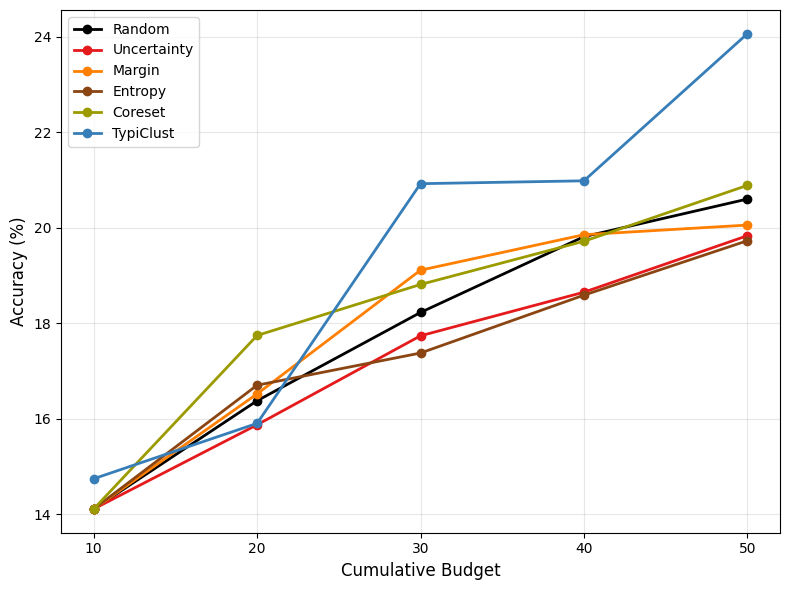

In [17]:
results_fully_supervised = {}
for name in ['Random', 'Uncertainty', 'Margin', 'Entropy', 'Coreset', 'TypiClust']:
    path = os.path.join(RESULTS_DIR, f'fully_supervised_{name}.npy')
    if os.path.exists(path):
        results_fully_supervised[name] = np.load(path)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cumulative_budgets = [(i + 1) * BUDGET for i in range(ITERATIONS)]

colors = {
    'Random': '#000000',
    'Uncertainty': '#e41a1c',
    'Margin': '#ff7f00',
    'Entropy': '#8b4513',
    'Coreset': '#9B9B00',
    'TypiClust': '#377eb8',
}

for name, accs in results_fully_supervised.items():
    mean_acc = accs.mean(axis=0)
    color = colors.get(name, None)
    ax.plot(cumulative_budgets, mean_acc, marker='o', label=name, linewidth=2, color=color)

ax.set_xlabel('Cumulative Budget', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(cumulative_budgets)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'results_fully_supervised.png'), dpi=150, bbox_inches='tight')
plt.show()

## Fully Supervised with Self-Supervised embeddings

For the fully supervised with self-supervised embeddings experiment, a linear classifier size  dxC (d is the feature dimension and C is the number of classes) was trained on the 512-d representations of data points selected by the active learning strategies, with a budget of 10 and 5 active learning iterations. To optimize this, the learning rate was set to 2.5 and the model was trained on 400 epochs. The training used the same configuration as the fully supervised framework.

### Baselines

In [18]:
def embedding_softmax_distributions(model, indices, batch_size=256):
    model.eval()
    all_probabilities = []

    with torch.no_grad():
        for start in range(0, len(indices), batch_size):
            batch_indices = indices[start:start + batch_size]
            batch_embeddings = embeddings_train[batch_indices].float().to(device)
            logits = model(batch_embeddings)
            probabilities = torch.softmax(logits, dim=1)
            all_probabilities.append(probabilities.cpu())

    return torch.cat(all_probabilities, dim=0)


def uncertainty_embeddings(budget, unlabelled_indices, labelled_indices=None, model=None):
    probabilities = embedding_softmax_distributions(model, unlabelled_indices)
    max_probabilities = probabilities.max(dim=1).values
    _, most_uncertain = max_probabilities.topk(budget, largest=False)
    return [unlabelled_indices[i] for i in most_uncertain.numpy()]

def margin_embeddings(budget, unlabelled_indices, labelled_indices=None, model=None):
    probabilities = embedding_softmax_distributions(model, unlabelled_indices)
    top2 = probabilities.topk(2, dim=1).values
    margins = top2[:, 0] - top2[:, 1]
    _, smallest_margin = margins.topk(budget, largest=False)
    return [unlabelled_indices[i] for i in smallest_margin.numpy()]

def entropy_embeddings(budget, unlabelled_indices, labelled_indices=None, model=None):
    probabilities = embedding_softmax_distributions(model, unlabelled_indices)
    ent = -(probabilities * (probabilities + 1e-10).log()).sum(dim=1)
    _, highest_entropy = ent.topk(budget, largest=True)
    return [unlabelled_indices[i] for i in highest_entropy.numpy()]

strategies_embeddings = [
    ('Random', random_uniformly),
    ('Uncertainty', uncertainty_embeddings),
    ('Margin', margin_embeddings),
    ('Entropy', entropy_embeddings),
    ('Coreset', coreset),
    ('TypiClust', typiClust),
]

### Training

In [19]:
EPOCHS = 400
LEARNING_RATE = 2.5
MOMENTUM = 0.9
BUDGET = 10

ITERATIONS = 5
REPETITIONS = 5

FEATURE_DIMENSION = 512
NUM_CLASSES = 10

embeddings_train, labels_train = representation_learning(dataset_train_self_supervised_embeddings)
embeddings_test, labels_test = representation_learning(dataset_test_self_supervised_embeddings)

def train_fully_supervised_with_embeddings(labelled_indices):
    selected_embeddings_train = embeddings_train[labelled_indices].clone().float().to(device)
    selected_labels_train = labels_train[labelled_indices].clone().long().to(device)

    all_embeddings_test = embeddings_test.float().to(device)
    all_labels_test = labels_test.long().to(device)

    linear_classifier = nn.Linear(FEATURE_DIMENSION, NUM_CLASSES).to(device)

    optimizer = optim.SGD(linear_classifier.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    loss_function = nn.CrossEntropyLoss()

    linear_classifier.train()
    pbar = tqdm(range(EPOCHS), desc="Training", leave=False)
    for epoch in pbar:
        optimizer.zero_grad()
        outputs = linear_classifier(selected_embeddings_train)
        loss = loss_function(outputs, selected_labels_train)
        loss.backward()
        optimizer.step()
        scheduler.step()

        if epoch % 50 == 0 or epoch == EPOCHS - 1:
            pbar.set_postfix(epoch=epoch, loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.4f}")

    linear_classifier.eval()
    with torch.no_grad():
        outputs = linear_classifier(all_embeddings_test)
        _, predicted = outputs.max(1)
        correct = predicted.eq(all_labels_test).sum().item()
        total = all_labels_test.size(0)

    accuracy = 100 * correct / total
    return accuracy, linear_classifier

### Experiment

In [20]:
def supervised_embeddings_experiment(strategy_name, selection_strategy):
    checkpoint_path = os.path.join(RESULTS_DIR, f'embeddings_{strategy_name}_checkpoint.npz')

    if os.path.exists(checkpoint_path):
        checkpoint = np.load(checkpoint_path)
        accuracies = checkpoint['accuracies']
        start_repitition = int(checkpoint['completed_reps'])
        print(f'{strategy_name}: Resuming from repetition {start_repitition + 1}/{REPETITIONS}')

        if REPETITIONS > accuracies.shape[0]:
            expanded = np.zeros((REPETITIONS, ITERATIONS))
            expanded[:accuracies.shape[0], :accuracies.shape[1]] = accuracies
            accuracies = expanded
    else:
        accuracies = np.zeros((REPETITIONS, ITERATIONS))
        start_repitition = 0

    for r in range(start_repitition, REPETITIONS):
        set_seed(r)
        labelled_indices = []
        model = None

        for i in range(ITERATIONS):
            unlabelled_indices = [idx for idx in range(NUM_TRAIN) if idx not in set(labelled_indices)]

            if model is None and selection_strategy != typiClust:
                queries = random_uniformly(BUDGET, unlabelled_indices)
            else:
                queries = selection_strategy(BUDGET, unlabelled_indices, labelled_indices, model)

            labelled_indices.extend(queries)
            accuracy, model = train_fully_supervised_with_embeddings(labelled_indices)
            accuracies[r, i] = accuracy

        np.savez(checkpoint_path, accuracies=accuracies, completed_reps=r + 1)
        print(f'{strategy_name}: Checkpoint saved after repetition {r + 1}')

    return accuracies

results_embeddings = {}
for name, fn in strategies_embeddings:
    result_path = os.path.join(RESULTS_DIR, f'embeddings_{name}.npy')
    if os.path.exists(result_path):
        print(f'{name}: Results already exist.')
        results_embeddings[name] = np.load(result_path)
    else:
        accs = supervised_embeddings_experiment(name, fn)
        results_embeddings[name] = accs
        np.save(result_path, accs)
        

Random: Results already exist.
Uncertainty: Results already exist.
Margin: Results already exist.
Entropy: Results already exist.
Coreset: Results already exist.
TypiClust: Results already exist.


### Plot

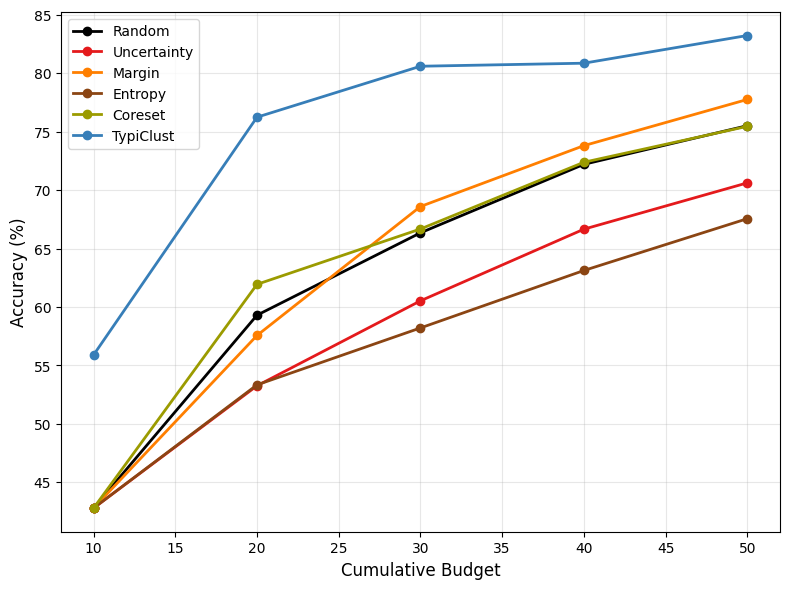

In [21]:
results_embeddings = {}
for name in ['Random', 'Uncertainty', 'Margin', 'Entropy', 'Coreset', 'TypiClust']:
    path = os.path.join(RESULTS_DIR, f'embeddings_{name}.npy')
    if os.path.exists(path):
        results_embeddings[name] = np.load(path)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cumulative_budgets = [(i + 1) * BUDGET for i in range(ITERATIONS)]

colors = {
    'Random': '#000000',
    'Uncertainty': '#e41a1c',
    'Margin': '#ff7f00',
    'Entropy': '#8b4513',
    'Coreset': '#9B9B00',
    'TypiClust': '#377eb8',
}

for name, accs in results_embeddings.items():
    mean_acc = accs.mean(axis=0)
    color = colors.get(name, None)
    ax.plot(cumulative_budgets, mean_acc, marker='o', label=name, linewidth=2, color=color)

ax.set_xlabel('Cumulative Budget', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'results_embeddings.png'), dpi=150, bbox_inches='tight')
plt.show()

## Semi-supervised

Semi supervised learning was implemented with FlexMatch. A wideResNet28 was trained for 100k iterations. 10 data points were chosen by the active learning strategies.  An SGD optimiser with 0.03 learning rate, batch size 64, 0.9 momentum, 0.0005 weight decay, 2 widen factor and 0.1 leaky slope was used, and without dropout.

### Selection Strategies

In [22]:
def random_selection(budget, unlabelled_indices=None, labelled_indices=None, model=None):
    """
    Select samples from the unlabelled pool randomly.
    """
    return list(np.random.choice(unlabelled_indices, size=budget, replace=False))

def balanced(budget, unlabelled_indices=None, labelled_indices=None, model=None):
    """
    Select an equal number of samples per class with budget=10 and classes=10.
    """
    num_classes = 10
    per_class = budget // num_classes

    all_train_labels = np.array([dataset_train[i][1] for i in range(NUM_TRAIN)])
    unlabelled_set = set(unlabelled_indices)

    selected = []
    # find all unlabled samples belonging to each class and randomly pick a data point from each class
    for c in range(num_classes):
        class_idx = np.where(all_train_labels == c)[0]
        class_idx = np.array([i for i in class_idx if i in unlabelled_set])
        chosen = np.random.choice(class_idx, size=min(per_class, len(class_idx)), replace=False)
        selected.extend(chosen.tolist())

    # if there are some data points left to be selected then pick randomly
    remaining = budget - len(selected)
    if remaining > 0:
        pool = [i for i in unlabelled_indices if i not in set(selected)]
        selected.extend(list(np.random.choice(pool, size=remaining, replace=False)))

    return selected

semi_supervised_strategies = [
    ('Random', random_selection),
    ('Balanced', balanced),
    ('Coreset', coreset),
    ('TypiClust', typiClust),
]

### Dataset

In [23]:
class AugmentedDataset(Dataset):
    """
    This class returns two different augmentations of the same image.
    """
    def __init__(self, dataset):
        self.dataset = dataset
        # weak augmentation: random crop and horizontal flip
        self.weak_transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ])

        # strong augmentation: random crop, horizontal flip, and 2 random augmentations
        self.strong_transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.RandAugment(num_ops=2, magnitude=10),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        return self.weak_transform(img), self.strong_transform(img), label, idx

### Model

In [24]:
class Block(nn.Module):
    """
    A residual block: BN->activation->conv.
    This is repeated twice in the forward pass.
    """
    def __init__(self, in_channels, out_channels, stride, leaky_slope=0.1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.leaky_slope = leaky_slope

        # a residual shortcut
        # use identity when the dimensions match, otherwise 1x1 conv to align channels
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False)

    def forward(self, x):
        output = self.conv1(F.leaky_relu(self.bn1(x), self.leaky_slope))
        output = self.conv2(F.leaky_relu(self.bn2(output), self.leaky_slope))
        return output + self.shortcut(x)


class WideResNet(nn.Module):
    def __init__(self, depth=28, widen_factor=2, num_classes=10, leaky_slope=0.1):
        super().__init__()
        """
        This network has 3 groups, each with 4 blocks.
        With an initial convolutional layer and a final fully connected layer.
        """
        n = (depth - 4) // 6

        channels = [16, 16 * widen_factor, 32 * widen_factor, 64 * widen_factor]

        self.conv1 = nn.Conv2d(3, channels[0], 3, stride=1, padding=1, bias=False)

        # 4 blocks at 32×32 spatial, 32 channels
        self.group1 = self.create_group(n, channels[0], channels[1], stride=1, leaky_slope=leaky_slope)
        # 4 blocks at 16×16 spatial, 64 channels
        self.group2 = self.create_group(n, channels[1], channels[2], stride=2, leaky_slope=leaky_slope)
        # 4 blocks at 8×8 spatial, 128 channels
        self.group3 = self.create_group(n, channels[2], channels[3], stride=2, leaky_slope=leaky_slope)

        self.bn = nn.BatchNorm2d(channels[3])
        self.leaky_slope = leaky_slope
        self.fc = nn.Linear(channels[3], num_classes)

        # loop through all layers in the network and set initial weights
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0.0)

    def create_group(self, num_blocks, in_channels, out_channels, stride, leaky_slope):
        """
        A group is a sequence of residual blocks that have the same spacial resolution
        """
        layers = [Block(in_channels, out_channels, stride, leaky_slope)]

        for _ in range(1, num_blocks):
            layers.append(Block(out_channels, out_channels, 1, leaky_slope))

        return nn.Sequential(*layers)

    def forward(self, x):
        """
        Forward pass: conv->3 groups->batch norm->activation->pooling->flatten->linear classifier
        """
        out = self.conv1(x)
        out = self.group1(out)
        out = self.group2(out)
        out = self.group3(out)
        out = F.leaky_relu(self.bn(out), self.leaky_slope)
        out = F.adaptive_avg_pool2d(out, 1)
        out = out.view(out.size(0), -1)
        return self.fc(out)

### Training

In [25]:
NUM_CLASSES = 10
ITERATIONS = 100000 # cut down from 400000
BATCH_SIZE = 64
MU = 7
TAU = 0.95
LAMBDA_U = 1.0
LR = 0.03
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005
EMA_DECAY = 0.999

def threshold_per_class(sigma, num_unlabelled):
    """
    sigma: counts how many unlabelled samples for each class have been assigned a pseudo-label

    This function accepts the per-class pseudo label count and returns a tensor
    of one threshold per class that determines how confident the model needs to
    be before accepting a pseudo label for the class.
    """

    num_unused = num_unlabelled - sigma.sum() # number of unlabled samples that have not been pseudo-labelled yet

    # normalise sigma
    if sigma.max() < num_unused:
        sig_norm = max(sigma.max().item(), num_unused.item())
    else:
        sig_norm = sigma.max().item()

    # when nothing has been pseudo labelled yet
    if sig_norm == 0:
        return torch.zeros(NUM_CLASSES, device=sigma.device)

    beta = sigma / sig_norm # per class: 1 = well learned, 0 = not learned
    mapped = beta / (2.0 - beta) # nonlinear mapping
    return mapped * TAU # convert to threshold

def train_flexmatch(labelled_indices):
    """
    This function trains the WideResNet on the CIFAR-10 training set using the FlexMatch semi-supervised algorithm.
    """
    dataset = AugmentedDataset(dataset_train)
    labelled_set = set(labelled_indices)
    unlabelled_indices = [i for i in range(NUM_TRAIN) if i not in labelled_set]
    num_unlabelled = len(unlabelled_indices)

    test_loader = DataLoader(normalised_test, batch_size=256, shuffle=False, num_workers=2)

    model = WideResNet(depth=28, widen_factor=2, num_classes=NUM_CLASSES).to(device) # trained with gradients
    ema_model = copy.deepcopy(model) # updated via exponential moving average

    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=ITERATIONS)

    # stores pseudo labels that model is confident about
    sample_predictions = torch.full((NUM_TRAIN,), -1, dtype=torch.long, device=device)

    model.train()
    pbar = tqdm(range(ITERATIONS), desc="FlexMatch Training", leave=True)
    for step in pbar:
        # sample labelled and unlabelled batches
        labelled_idx = random.choices(list(labelled_indices), k=BATCH_SIZE)
        unlabelled_idx = random.choices(unlabelled_indices, k=BATCH_SIZE * MU)

        # collate into batches
        labelled_weak, _, labelled_labels, _ = default_collate([dataset[i] for i in labelled_idx])
        unlabelled_weak, unlabelled_strong, _, unlabelled_dataset_idx = default_collate([dataset[i] for i in unlabelled_idx])

        labelled_weak, labelled_labels = labelled_weak.to(device), labelled_labels.to(device)
        unlabelled_weak, unlabelled_strong = unlabelled_weak.to(device), unlabelled_strong.to(device)

        # supervised loss
        loss_supervised = F.cross_entropy(model(labelled_weak), labelled_labels)

        ema_model.eval()
        with torch.no_grad():
            logits_weak = ema_model(unlabelled_weak)
            probs = F.softmax(logits_weak, dim=1)
            max_probs, pseudo_labels = probs.max(dim=1)

        ema_model.train()

        # pseudo label generation
        sigma = torch.zeros(NUM_CLASSES, device=device)
        for c in range(NUM_CLASSES):
            sigma[c] = (sample_predictions == c).sum().float()

        flex_thresholds = threshold_per_class(sigma, num_unlabelled)

        per_sample_threshold = flex_thresholds[pseudo_labels]
        mask = max_probs.ge(per_sample_threshold).float()

        with torch.no_grad():
            for i, global_idx in enumerate(unlabelled_idx):
                if max_probs[i] >= per_sample_threshold[i]:
                    sample_predictions[global_idx] = pseudo_labels[i]

        # unsupervised loss
        loss_unsupervised = (F.cross_entropy(model(unlabelled_strong), pseudo_labels, reduction='none') * mask).mean()

        loss = loss_supervised + LAMBDA_U * loss_unsupervised

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        # ema update
        with torch.no_grad():
            for ema_p, p in zip(ema_model.parameters(), model.parameters()):
                ema_p.data.mul_(EMA_DECAY).add_(p.data, alpha=1 - EMA_DECAY)

        pbar.set_postfix(loss=f"{loss.item():.4f}", mask=f"{mask.mean().item():.2f}", lr=f"{scheduler.get_last_lr()[0]:.5f}")

    # evaluate model performance
    ema_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds = ema_model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = 100.0 * correct / total
    return accuracy

### Experiment

In [26]:
BUDGET = 10
REPETITIONS = 1

def semi_supervised_experiments(strategy_name, selection_strategy):
    checkpoint_path = os.path.join(RESULTS_DIR, f'semi_supervised_{strategy_name}_checkpoint.json')

    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, 'r') as f:
            checkpoint = json.load(f)
        accuracies = checkpoint['accuracies']
        start_repetition = checkpoint['completed_reps']
        print(f'{strategy_name}: Starting from repetition {start_repetition + 1}/{REPETITIONS}')
    else:
        accuracies = []
        start_repetition = 0

    for r in range(start_repetition, REPETITIONS):
        set_seed(r)

        unlabelled_indices = list(range(NUM_TRAIN))
        selected = selection_strategy(BUDGET, unlabelled_indices, [])

        accuracy = train_flexmatch(selected)
        accuracies.append(accuracy)

        with open(checkpoint_path, 'w') as f:
            json.dump({'accuracies': accuracies, 'completed_reps': r + 1}, f)
        print(f'{strategy_name}: Checkpoint saved after repetition {r + 1}')

    return accuracies

results_semi_supervised = {}
result_path = os.path.join(RESULTS_DIR, 'semi_supervised.json')

if os.path.exists(result_path):
    print('Results already exist.')
    with open(result_path, 'r') as f:
        results_semi_supervised = json.load(f)
else:
    for name, fn in semi_supervised_strategies:
        accs = semi_supervised_experiments(name, fn)
        results_semi_supervised[name] = accs

    with open(result_path, 'w') as f:
        json.dump(results_semi_supervised, f)

Results already exist.


### Plot

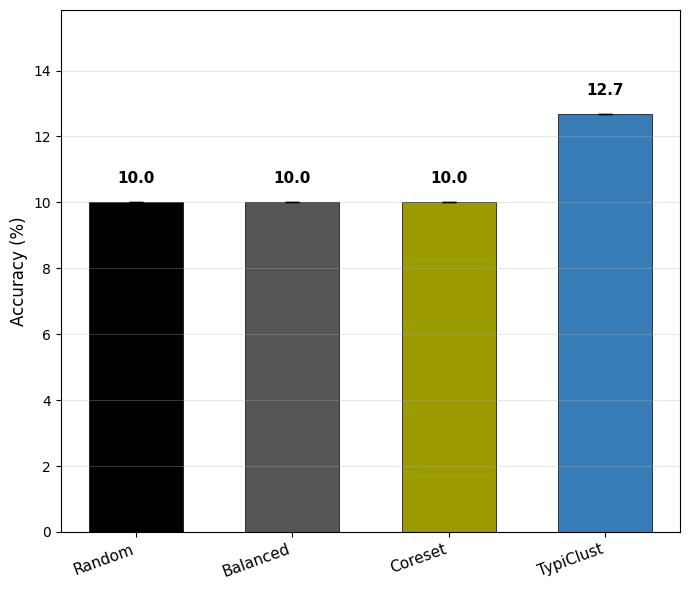

In [27]:
with open(os.path.join(RESULTS_DIR, 'semi_supervised.json'), 'r') as f:
    results_semi_supervised = json.load(f)

strategy_names = list(results_semi_supervised.keys())
means = [np.mean(results_semi_supervised[name]) for name in strategy_names]
std_errors = [np.std(results_semi_supervised[name]) / np.sqrt(len(results_semi_supervised[name])) for name in strategy_names]

bar_colors = {
    'Random': '#000000',
    'Balanced': '#555555',
    'Coreset': '#9B9B00',
    'TypiClust': '#377eb8',
}

fig, ax = plt.subplots(figsize=(7, 6))
x = np.arange(len(strategy_names))
colors = [bar_colors.get(name, '#8B008B') for name in strategy_names]

bars = ax.bar(x, means, yerr=std_errors, capsize=5, color=colors, width=0.6, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(strategy_names, fontsize=11, rotation=20, ha='right')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(means) * 1.25)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'results_semi_supervised.png'), dpi=150, bbox_inches='tight')
plt.show()

## Accuracy Gains with TypiClust

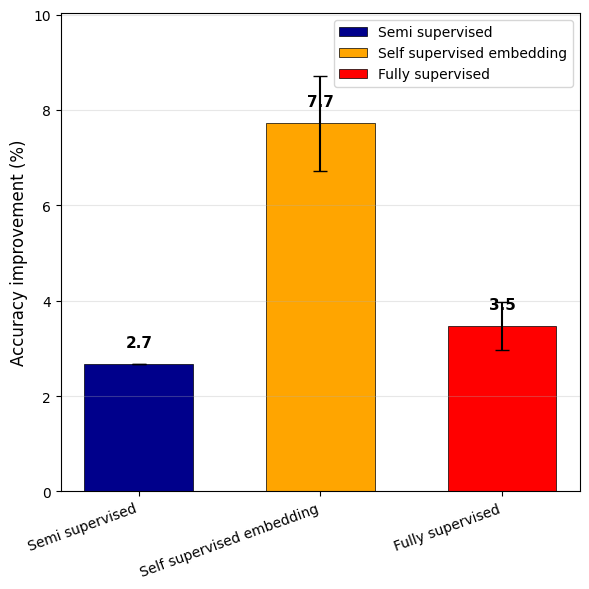

In [28]:
"""
Only look at final iteration for each experiment
"""
results_fully_supervised = {}
for name in ['Random', 'TypiClust']:
    path = os.path.join(RESULTS_DIR, f'fully_supervised_{name}.npy')
    if os.path.exists(path):
        results_fully_supervised[name] = np.load(path)

results_embeddings = {}
for name in ['Random', 'TypiClust']:
    path = os.path.join(RESULTS_DIR, f'embeddings_{name}.npy')
    if os.path.exists(path):
        results_embeddings[name] = np.load(path)

with open(os.path.join(RESULTS_DIR, 'semi_supervised.json'), 'r') as f:
    results_semi_supervised = json.load(f)

# fully supervised
fs_random = results_fully_supervised['Random'][:, -1]
fs_typiclust = results_fully_supervised['TypiClust'][:, -1]
fs_improvement = fs_typiclust.mean() - fs_random.mean()
fs_error = np.sqrt(fs_typiclust.std()**2 + fs_random.std()**2) / np.sqrt(len(fs_random))

# self-supervised embeddings
sse_random = results_embeddings['Random'][:, -1]
sse_typiclust = results_embeddings['TypiClust'][:, -1]
sse_improvement = sse_typiclust.mean() - sse_random.mean()
sse_error = np.sqrt(sse_typiclust.std()**2 + sse_random.std()**2) / np.sqrt(len(sse_random))

# semi-supervised
semi_random = np.array(results_semi_supervised['Random'])
semi_typiclust = np.array(results_semi_supervised['TypiClust'])
semi_improvement = semi_typiclust.mean() - semi_random.mean()
semi_error = np.sqrt(semi_typiclust.std()**2 + semi_random.std()**2) / np.sqrt(len(semi_random))

improvements = [semi_improvement, sse_improvement, fs_improvement]
errors = [semi_error, sse_error, fs_error]
bar_colors = ['#00008B', '#FFA500', '#FF0000']
labels = ['Semi supervised', 'Self supervised embedding', 'Fully supervised']

fig, ax = plt.subplots(figsize=(6, 6))
x = np.arange(3)
width = 0.6

bars = ax.bar(x, improvements, width, yerr=errors, capsize=5, color=bar_colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, improvements):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10, rotation=20, ha='right')
ax.set_ylabel('Accuracy improvement (%)', fontsize=12)
ax.legend(bars, labels, fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(improvements) * 1.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'results_random_typiclust.png'), dpi=150, bbox_inches='tight')
plt.show()

# Algorithm Modification

The proposed modification is to replace the use of K-means and KNN typicality with a single gaussian model (GMM).


In [29]:
REDUCED_DIM = 50
MAX_CLUSTERS = 500
MIN_CLUSTER_SIZE = 5

def typiClustGMM(budget, unlabelled_indices, labelled_indices, model=None, embeddings_reduced=None):
    """
    This variant of typiClust is TPC_RP which uses a Gaussian Mixture Model instead of
    K-Means clustering and KNN-based typicality.
    """

    # extract the feature vectors using the penultimate layer of the trained model
    if os.path.exists(EMBEDDING_PATH):
        embeddings = torch.load(EMBEDDING_PATH)
    else:
        embeddings, _ = representation_learning(normalised_train)
        torch.save(embeddings, EMBEDDING_PATH)

    embeddings_np = embeddings.numpy()

    if embeddings_reduced is None:
      reducer = GaussianRandomProjection(n_components=REDUCED_DIM, random_state=42)
      embeddings_reduced = reducer.fit_transform(embeddings_np)

    queries = []
    labelled_set = set(labelled_indices)

    # cluster the data
    num_clusters = min(len(set(labelled_indices)) + budget, MAX_CLUSTERS)
    gmm = GaussianMixture(n_components=num_clusters, covariance_type='diag', max_iter=300, n_init=3, random_state=42)
    cluster_assignments = gmm.fit_predict(embeddings_reduced)

    # per-point log-likelihood
    per_point_log_likelihood = gmm.score_samples(embeddings_reduced)

    # group together datapoints in the same clusters
    clusters = {}
    for idx, c in enumerate(cluster_assignments):
        c = int(c)
        if c not in clusters:
            clusters[c] = []
        clusters[c].append(idx)

    # query one unlabelled data point for each iteration in allowed budget
    for _ in range(budget):
        best_cluster = None
        least_labelled_count = float('inf')
        largest_cluster_size = -1

        # go through all clusters
        for cluster_class, data_indices in clusters.items():
            # clusters with less than 5 samples are dropped
            if len(data_indices) < MIN_CLUSTER_SIZE:
                continue

            # number of labelled data points in this cluster
            labelled_count_in_cluster = len(set(data_indices) & labelled_set)

            # find largest cluster with the fewest labelled points
            less_labelled = labelled_count_in_cluster < least_labelled_count
            cluster_is_larger = (labelled_count_in_cluster == least_labelled_count and len(data_indices) > largest_cluster_size)

            if less_labelled or cluster_is_larger:
                least_labelled_count = labelled_count_in_cluster
                largest_cluster_size = len(data_indices)
                best_cluster = cluster_class

        if best_cluster is None:
            break

        # get unlabelled data points
        cluster_data_indices = clusters[best_cluster]
        unlabelled_data_indices = [idx for idx in cluster_data_indices if idx not in labelled_set]

        if len(unlabelled_data_indices) == 0:
            del clusters[best_cluster]
            continue

        # select the point with highest log-likelihood
        best_score = -float('inf')
        most_typical_idx = None
        for dataset_idx in unlabelled_data_indices:
            score = per_point_log_likelihood[dataset_idx]
            if score > best_score:
                best_score = score
                most_typical_idx = dataset_idx

        queries.append(most_typical_idx)
        labelled_set.add(most_typical_idx)

    return queries

## Dimensionality Reduction Experiment

This experiment evaluates the effect of different dimensionality reduction methods on model accuracy, using the fully supervised with self supervised embeddings experiment.

In [30]:
ITERATIONS = 5
REPETITIONS = 1
REDUCED_DIM = 50
BUDGET = 10

def dim_reduction_experiment():
    results = {}

    reductions = ['pca', 'umap', 'rp']

    # extract the feature vectors using the penultimate layer of the trained model
    if os.path.exists(EMBEDDING_PATH):
        embeddings = torch.load(EMBEDDING_PATH)
    else:
        embeddings, _ = representation_learning(normalised_train)
        torch.save(embeddings, EMBEDDING_PATH)

    embeddings_np = embeddings.numpy()

    for reduction in reductions:
        if reduction == 'pca':
            reducer = PCA(n_components=REDUCED_DIM, random_state=42)
            embeddings_reduced = reducer.fit_transform(embeddings_np)
        elif reduction == 'umap':
            reducer = umap.UMAP(n_components=REDUCED_DIM, n_neighbors=30, min_dist=0.0, metric='euclidean', random_state=42)
            embeddings_reduced = reducer.fit_transform(embeddings_np)
        elif reduction == 'rp':
            reducer = GaussianRandomProjection(n_components=REDUCED_DIM, random_state=42)
            embeddings_reduced = reducer.fit_transform(embeddings_np)

        accuracies = np.zeros((REPETITIONS, ITERATIONS))

        for r in range(REPETITIONS):
            set_seed(r)

            labelled_indices = []

            for i in range(ITERATIONS):
                unlabelled_indices = [idx for idx in range(NUM_TRAIN) if idx not in set(labelled_indices)]
                queries = typiClustGMM(BUDGET, unlabelled_indices, labelled_indices, None, embeddings_reduced)
                labelled_indices.extend(queries)
                accuracy, _ = train_fully_supervised_with_embeddings(labelled_indices)
                accuracies[r, i] = accuracy

        results[reduction] = accuracies

    return results
 
result_names = ['pca', 'umap', 'rp']
all_exist = all(os.path.exists(os.path.join(RESULTS_DIR, f'dim_reduction_{name}.npy')) for name in result_names)

if all_exist:
    print("Results already exist.")
else:
    results_dim_reduction = dim_reduction_experiment()

    for name, accs in results_dim_reduction.items():
        np.save(os.path.join(RESULTS_DIR, f'dim_reduction_{name}.npy'), accs)

Results already exist.


### Plot for dimensionality reduction

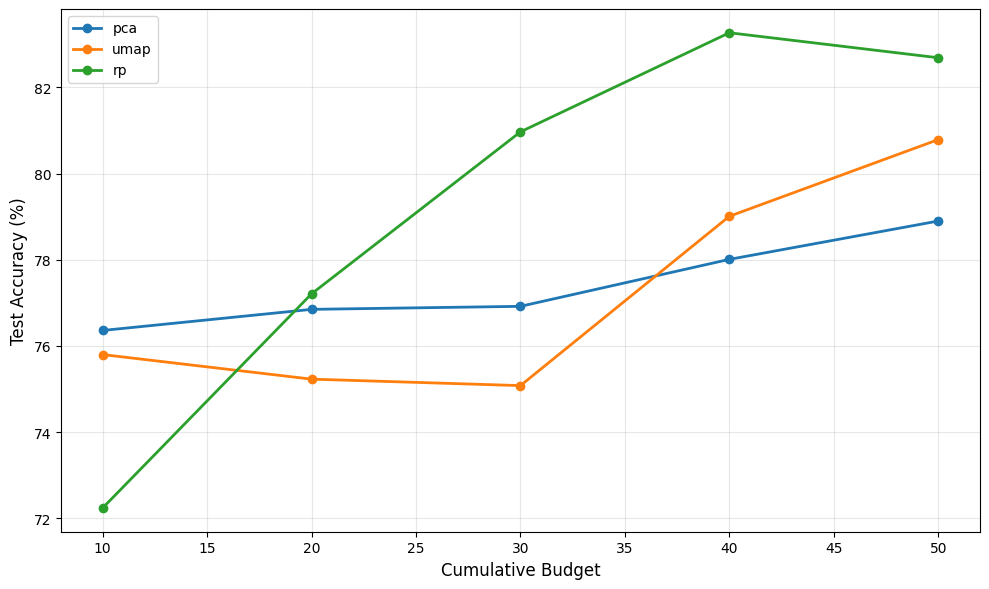

In [31]:
results_dim_reduction = {}
for name in ['pca', 'umap', 'rp']:
    path = os.path.join(RESULTS_DIR, f'dim_reduction_{name}.npy')
    if os.path.exists(path):
        results_dim_reduction[name] = np.load(path)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
cumulative_budgets = [(i + 1) * BUDGET for i in range(ITERATIONS)]

for name, results in results_dim_reduction.items():
    mean_acc = results.mean(axis=0)
    ax.plot(cumulative_budgets, mean_acc, marker='o', label=name, linewidth=2)

    if REPETITIONS > 1:
        std_acc = results.std(axis=0)
        ax.fill_between(cumulative_budgets, mean_acc - std_acc, mean_acc + std_acc, alpha=0.15)

ax.set_xlabel('Cumulative Budget', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'results_dim_reduction.png'), dpi=150, bbox_inches='tight')
plt.show()

## Evaluation against original implementation

This experiment evaluates the perfomance of TypiClust vs TypiClustGMM using the fully supervised with self-supervised embeddings experiment.

In [32]:
ITERATIONS = 5
REPETITIONS = 1
REDUCED_DIM = 50
BUDGET = 10

strategies = [
    ('TypiClust', typiClust),
    ('TypiClustGMM', typiClustGMM),
]

def comparison_experiment():
    all_results = {}

    for name, strategy in strategies:
      results = np.zeros((REPETITIONS, ITERATIONS))

      for r in range(REPETITIONS):
          set_seed(r)
          labelled_indices = []

          for i in range(ITERATIONS):
              unlabelled_indices = [idx for idx in range(NUM_TRAIN) if idx not in set(labelled_indices)]
              queries = strategy(BUDGET, unlabelled_indices, labelled_indices)
              labelled_indices.extend(queries)
              accuracy, _  = train_fully_supervised_with_embeddings(labelled_indices)
              results[r, i] = accuracy

      all_results[name] = results

    return all_results

result_names = ['TypiClust', 'TypiClustGMM']
all_exist = all(os.path.exists(os.path.join(RESULTS_DIR, f'comparison_{name}.npy')) for name in result_names)

if all_exist:
    print("Results already exist.")
else:
    results_comparison = comparison_experiment()

    for name, accs in results_comparison.items():
        np.save(os.path.join(RESULTS_DIR, f'comparison_{name}.npy'), accs)

Results already exist.


### Plot for results comparison

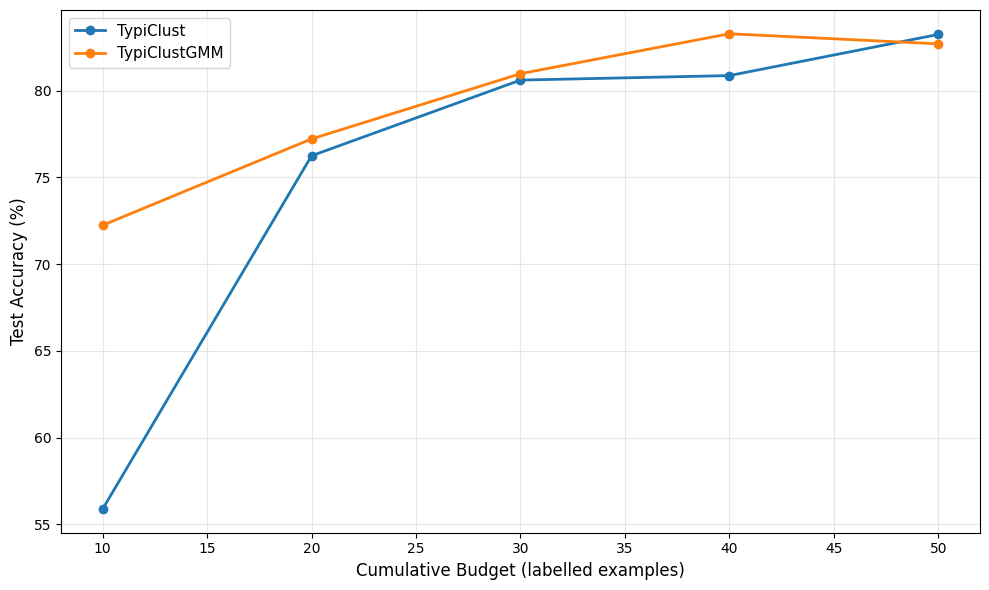

In [33]:
results_comparison = {}
for name in ['TypiClust', 'TypiClustGMM']:
    path = os.path.join(RESULTS_DIR, f'comparison_{name}.npy')
    if os.path.exists(path):
        results_comparison[name] = np.load(path)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
cumulative_budgets = [(i + 1) * BUDGET for i in range(ITERATIONS)]

colors = {'TypiClust': '#1f77b4', 'TypiClustGMM': '#ff7f0e'}

for name, results in results_comparison.items():
    mean_acc = results.mean(axis=0)
    color = colors.get(name, None)
    ax.plot(cumulative_budgets, mean_acc, marker='o', label=name, linewidth=2, color=color)

    if REPETITIONS > 1:
        std_acc = results.std(axis=0)
        ax.fill_between(cumulative_budgets, mean_acc - std_acc, mean_acc + std_acc, alpha=0.15, color=color)

ax.set_xlabel('Cumulative Budget (labelled examples)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'results_modification_original.png'), dpi=150, bbox_inches='tight')
plt.show()

In [38]:
print("Accuracy at Budget = 10:")
for name, results in results_comparison.items():
    mean_acc = results.mean(axis=0)[0]
    if REPETITIONS > 1:
        std_acc = results.std(axis=0)[0]
        print(f"{name}: {mean_acc:.2f}% ± {std_acc:.2f}%")
    else:
        print(f"{name}: {mean_acc:.2f}%")

print("Mean accuracy improvement across all iterations:")
baseline = results_comparison['TypiClust'].mean(axis=0)
modified = results_comparison['TypiClustGMM'].mean(axis=0)
improvements = modified - baseline
mean_improvement = improvements.mean()
print(f"{mean_improvement:.2f}%")

Accuracy at Budget = 10:
TypiClust: 55.89%
TypiClustGMM: 72.24%
Mean accuracy improvement across all iterations:
3.91%


# Summary Table

The table below displays top-1 test accuracy on CIFAR-10 for each experiment conducted for results replication.

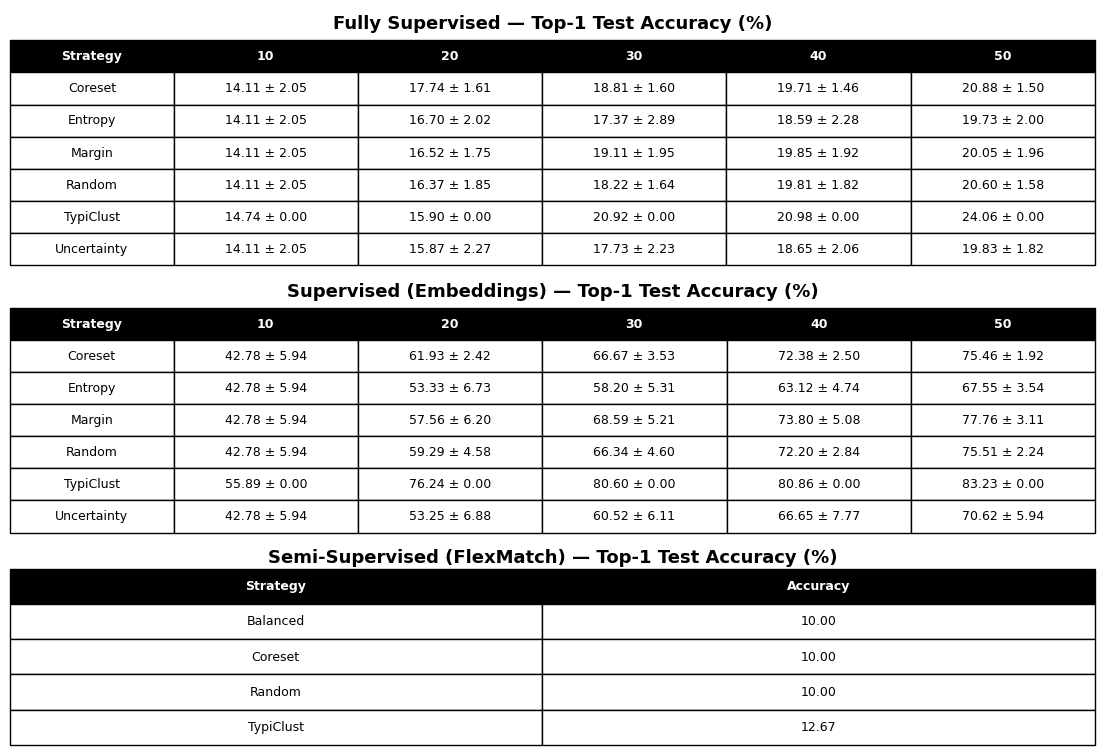

In [35]:
BUDGET = 10

with open(os.path.join(RESULTS_DIR, 'semi_supervised.json'), 'r') as f:
    results_semi_supervised = json.load(f)

results_fully_supervised = {}
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, 'fully_supervised_*.npy'))):
    name = os.path.basename(path).replace('fully_supervised_', '').replace('.npy', '')
    results_fully_supervised[name] = np.load(path)

results_embeddings = {}
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, 'embeddings_*.npy'))):
    name = os.path.basename(path).replace('embeddings_', '').replace('.npy', '')
    results_embeddings[name] = np.load(path)

fs_iterations = max((accs.shape[1] for accs in results_fully_supervised.values()), default=0)
emb_iterations = max((accs.shape[1] for accs in results_embeddings.values()), default=0)

def create_rows(results_dict, num_iterations):
    rows = []
    for name, accs in sorted(results_dict.items()):
        row = [name]
        for i in range(num_iterations):
            mean = np.mean(accs[:, i])
            std = np.std(accs[:, i])
            if accs.shape[0] > 1:
                row.append(f"{mean:.2f} \u00b1 {std:.2f}")
            else:
                row.append(f"{mean:.2f}")
        rows.append(row)
    return rows

def create_rows_semi_supervised(results_dict):
    rows = []
    for name, accs in sorted(results_dict.items()):
        mean = np.mean(accs)
        std = np.std(accs) if len(accs) > 1 else 0
        row = [name]
        if std > 0:
            row.append(f"{mean:.2f} \u00b1 {std:.2f}")
        else:
            row.append(f"{mean:.2f}")
        rows.append(row)
    return rows

sections = []

if results_fully_supervised:
    fs_cols = ['Strategy'] + [f'{(i+1)*BUDGET}' for i in range(fs_iterations)]
    fs_rows = create_rows(results_fully_supervised, fs_iterations)
    sections.append(('Fully Supervised \u2014 Top-1 Test Accuracy (%)', fs_cols, fs_rows))

if results_embeddings:
    emb_cols = ['Strategy'] + [f'{(i+1)*BUDGET}' for i in range(emb_iterations)]
    emb_rows = create_rows(results_embeddings, emb_iterations)
    sections.append(('Supervised (Embeddings) \u2014 Top-1 Test Accuracy (%)', emb_cols, emb_rows))

if results_semi_supervised:
    semi_cols = ['Strategy', 'Accuracy']
    semi_rows = create_rows_semi_supervised(results_semi_supervised)
    sections.append(('Semi-Supervised (FlexMatch) \u2014 Top-1 Test Accuracy (%)', semi_cols, semi_rows))

section_heights = []
for title, col_labels, table_data in sections:
    h = len(table_data) * 0.35 + 0.35 + 0.5 + 0.3
    section_heights.append(h)

total_height = sum(section_heights) + 0.5
fig_width = 14

fig, axes = plt.subplots(
    len(sections), 1,
    figsize=(fig_width, total_height),
    gridspec_kw={'height_ratios': section_heights, 'hspace': 0.05}
)
if len(sections) == 1:
    axes = [axes]

for ax, (title, col_labels, table_data) in zip(axes, sections):
    ax.axis('off')
    ax.text(0.5, 0.98, title, transform=ax.transAxes, fontsize=13, fontweight='bold', ha='center', va='top')

    table = ax.table(cellText=table_data, colLabels=col_labels, cellLoc='center',loc='upper center', bbox=[0.0, 0.0, 1.0, 0.88])

    for (i, j), cell in table.get_celld().items():
        cell.set_text_props(ha='center', va='center')

    table.auto_set_font_size(False)
    table.set_fontsize(9)

    for j in range(len(col_labels)):
        cell = table[0, j]
        cell.set_facecolor("#000000")
        cell.set_text_props(color='white', fontweight='bold', fontsize=9, ha='center')

    for i in range(len(table_data)):
        for j in range(len(col_labels)):
            cell = table[i + 1, j]
            cell.set_facecolor('white')

    table.auto_set_column_width(list(range(len(col_labels))))

plt.savefig(os.path.join(PLOTS_DIR, 'results_table.png'), dpi=150, bbox_inches='tight')
plt.show()